**Group information**

| Family name | First name | Email address        |
| ----------- | ---------- | -------------------- |
| Fraley      | Samuel     | samuel.fraley@bse.eu |
| Reçica      | Olta       | olta.recica@bse.eu   |

# Semantic segmentation - Homework

This tutorial explores how to automatically extract building footprints from aerial images. The objective is to perform semantic segmentation, or approximate the function that maps input images to class probabilities for each pixel. For this assignment, we use the U-Net convolutional network architecture [(Ronneberger et al. 2015)](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28). The GPU implementation of PyTorch is recommended.

The image dataset consists of 3347 colour images, each with dimensions $3 \times 256 \times 256$, sourced from [Minh (2013)](http://www.cs.toronto.edu/~vmnih/data/). Each image corresponds to a 300-square-metre area within the state of Massachusetts. The labels are building footprint vectors derived from [OpenStreetMap](https://www.openstreetmap.org/relation/61315), which have been rasterised into binary masks matching the spatial extent and resolution of the input images. For efficient storage, images and labels are saved in the JPEG format.

![U-Net model](https://www.dropbox.com/scl/fi/wgvqiix6scbm1c983ephk/segmentation_model.jpg?rlkey=71blfq7cm1yzw26puu4l0ybhs&dl=1)

In [1]:
# Packages
import os
import shutil
import torch
import tqdm

from matplotlib import pyplot as plt
from torch import nn, optim, utils
from torchmetrics import classification
from torchvision import io, ops
from urllib import request

# Device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(device)

# Utilities
classes = {0:'non-building', 255:'building'}

/Users/oltarecica/Desktop/DL in Image Processing /sessions/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Utilities
def download_data():
    if os.getcwd().endswith('/data'):
        print('Data folder already exists')
    else:
        request.urlretrieve('https://www.dropbox.com/scl/fo/90urs56ftly5r28jk18i4/AB2AIFdymQmeEqJZ8Og0V4Q?rlkey=nkb2w0fmfuym7sbgqpqnvm9cd&dl=1', 'data.zip')
        shutil.unpack_archive('data.zip', 'data')
        os.remove('data.zip')
        os.chdir('data')

def display_image(image:torch.Tensor, title:str='', cmap:str='gray', figsize=(5, 5)) -> None:
    image   = torch.einsum('dhw -> hwd', image)
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    plt.close()

1. Load the images and labels as `torch.Tensor` of dimensions $n \times d \times h \times w$. Normalise the images and labels between 0 and 1 and set the data type as `torch.float32`.

<small>Note: In the label images, pixel values of 0 indicate non-building areas, while 255 indicate buildings. Due to JPEG's lossy compression, some values may slightly differ from 0 or 255. You can round the pixel values to restore binary labels.</small>

In [3]:
# Downloads data
download_data()

# Loads images and labels
image_files = sorted(os.listdir('images'))
label_files = sorted(os.listdir('labels'))

images = torch.stack([io.read_image(f'images/{f}') for f in tqdm.tqdm(image_files, desc='Loading images')])
labels = torch.stack([io.read_image(f'labels/{f}') for f in tqdm.tqdm(label_files, desc='Loading labels')])

# Normalises to [0, 1] and converts to float32
images = images.float() / 255.0
labels = (labels.float() / 255.0).round()

Loading labels: 100%|██████████| 3347/3347 [00:00<00:00, 7328.73it/s]


2. Check the array dimensions and display several image–label pairs to ensure that they are correctly aligned.

In [4]:
# 1. File count and name pairing
assert len(image_files) == len(label_files), \
    f"Count mismatch: {len(image_files)} images vs {len(label_files)} labels"

image_stems = [os.path.splitext(f)[0].replace('image_', '') for f in image_files]
label_stems = [os.path.splitext(f)[0].replace('label_', '') for f in label_files]
mismatched = [(i, l) for i, l in zip(image_stems, label_stems) if i != l]
assert not mismatched, f"Mismatched pairs: {mismatched[:5]}"

# 2. Spatial dimensions
assert images.shape[2:] == torch.Size([256, 256]), f"Unexpected image size: {images.shape}"
assert labels.shape[2:] == torch.Size([256, 256]), f"Unexpected label size: {labels.shape}"

# 3. Channel count
assert images.shape[1] == 3, f"Expected 3-channel images, got {images.shape[1]}"
assert labels.shape[1] == 1, f"Expected 1-channel labels, got {labels.shape[1]}"

# 4. Value ranges
assert images.min() >= 0.0 and images.max() <= 1.0, "Image values out of [0,1]"
unique_label_vals = labels.unique()
assert set(unique_label_vals.tolist()).issubset({0.0, 1.0}), \
    f"Unexpected label values: {unique_label_vals}"

# 5. NaN / Inf
assert not torch.isnan(images).any(), "NaN detected in images"
assert not torch.isinf(images).any(), "Inf detected in images"

# 6. Degenerate images
per_image_std = images.flatten(1).std(dim=1)
degenerate = (per_image_std == 0).nonzero(as_tuple=True)[0]
if len(degenerate):
    print(f"Warning: {len(degenerate)} potentially corrupt images (zero std): indices {degenerate.tolist()}")

print("All checks passed.")


All checks passed.


Images shape: torch.Size([3347, 3, 256, 256])
Labels shape: torch.Size([3347, 1, 256, 256])


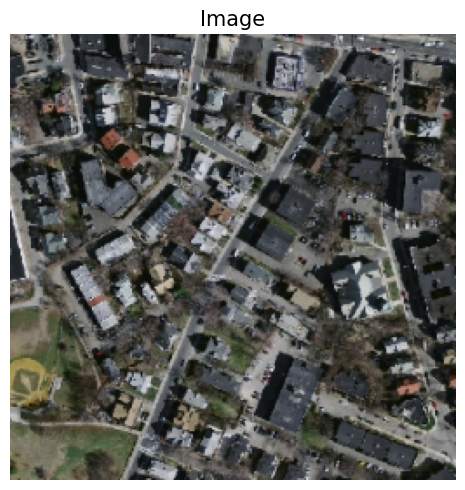

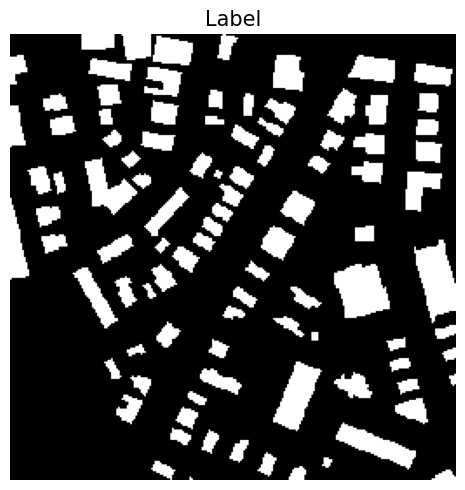

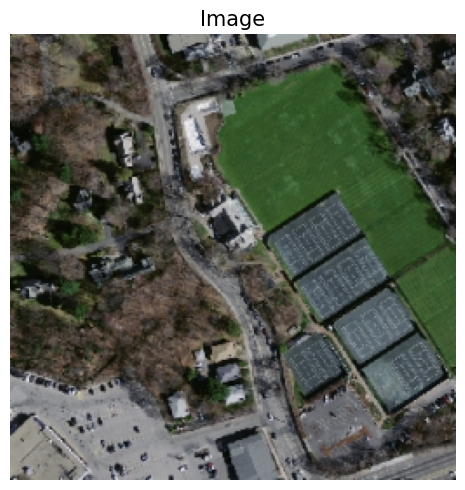

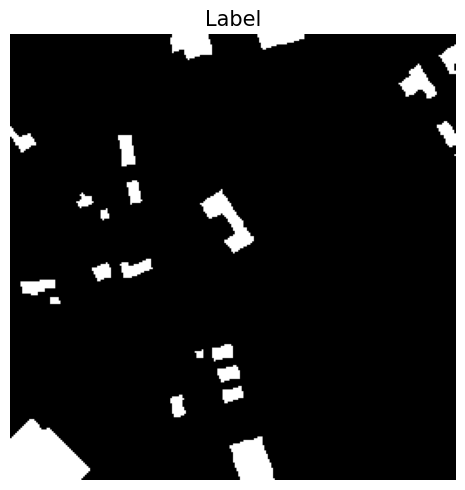

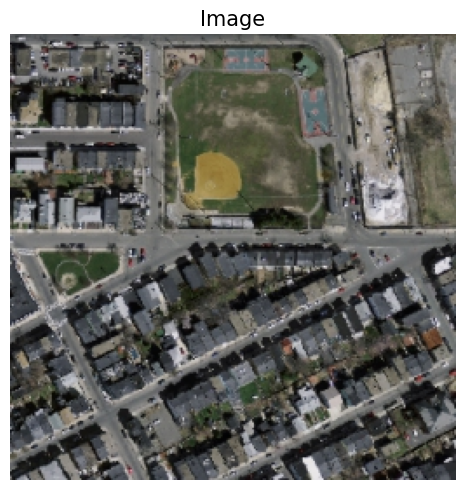

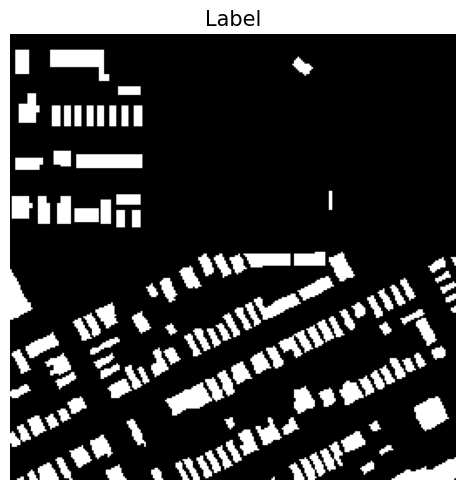

In [5]:
# Check dimensions
print('Images shape:', images.size())
print('Labels shape:', labels.size())

# Display random image-label pairs
for i in torch.randint(0, len(images), (3,)):
    display_image(image=images[i], title='Image')
    display_image(image=labels[i], title='Label')
del i

Before training we added a validation loop to check integrity of the dataset. We verified that the number of image and label files are equal, each pair is correctly  aligned by coordinate ids, confirmed the dimensions and RGB channels are consistent. We also ensure that all pixel values fall within 0 to 1 after normalization and they are binary after rounding.  Finally, we double checked that there were no NaN or Inf values or potentially corrupt images via checking for zero standard deviation. All checks passed.

As a result, we confirm images and labels have the correct dimensions and are well aligned, with building footprints in the masks matching the buildings visible in the aerial images. We also notice that some tiles contain no buildings at all, shown by completely black label masks. This suggests a class imbalance in the dataset since building pixels represent only a small fraction of all pixels, which we will need to account for when choosing our loss function.

3. Format the data as a `TensorDataset` and partition the observations into training (75%) and test (25%) samples. For each sample, create a `DataLoader` with a batch size suitable for your hardware (e.g. between 32 and 256).

<small>Note: Optionally, you can also include a validation sample by splitting the dataset into 70% training, 15% validation, and 15% test.</small>

We format the data as a TensorDataset and split it into training (70%), validation (15%) and test (15%) samples. We included a validation set because it allows us to monitor the model's performance on unseen data during training and apply early stopping to prevent overfitting. We use a batch size of 32 which is suitable for our hardware. The training loader uses shuffle=True to ensure the model does not learn any ordering in the data, while the validation and test loaders use shuffle=False to keep evaluation consistent.

In [6]:
import numpy as np

# Draw training, validation and test indices
np.random.seed(0)
samples = np.random.choice(['train', 'valid', 'test'], len(images), p=[0.70, 0.15, 0.15])

# Initialise datasets
train_dataset = utils.data.TensorDataset(images[samples == 'train'], labels[samples == 'train'])
valid_dataset = utils.data.TensorDataset(images[samples == 'valid'], labels[samples == 'valid'])
test_dataset  = utils.data.TensorDataset(images[samples == 'test'],  labels[samples == 'test'])

# Initialise data loaders
train_loader = utils.data.DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
valid_loader = utils.data.DataLoader(dataset=valid_dataset, batch_size=32, shuffle=False)
test_loader  = utils.data.DataLoader(dataset=test_dataset,  batch_size=32, shuffle=False)

In [7]:
# quick check

x, y = next(iter(train_loader))
print(f'Images shape: {x.size()}\nLabels shape: {y.size()}')
del x, y

Images shape: torch.Size([32, 3, 256, 256])
Labels shape: torch.Size([32, 1, 256, 256])


4. Using PyTorch, define a simplified U-Net model with the number of filters indicated in the figure above (i.e. 8, 16, 32, 64, 128, ...). Choose the appropriate activation functions for the hidden layers and the output layer.

<small>Note: Optionally, you can include batch normalisation and spatial dropout layers to improve the model’s optimisation and generalisation, respectively.</small>

We implement a simplified U-Net with filter sizes 8, 16, 32, 64 and 128 as specified. We include batch normalisation and spatial dropout in each block to stabilise training and improve generalisation. Skip connections allow the decoder to recover spatial details from the encoder at each resolution level. The output layer has a single filter with no activation, since we will apply sigmoid internally through the loss function.

In [8]:
def conv_block(in_channels:int, out_channels:int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.Dropout2d(p=0.1)
    )

class UNet(nn.Module):

    def __init__(self, input_channels:int=3, output_channels:int=1) -> None:
        super().__init__()
        # Encoder
        self.encoder1   = conv_block(input_channels, 8)
        self.encoder2   = conv_block(8, 16)
        self.encoder3   = conv_block(16, 32)
        self.encoder4   = conv_block(32, 64)
        self.pool       = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = conv_block(64, 128)
        # Decoder
        self.upsample   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.decoder4   = conv_block(128 + 64, 64)
        self.decoder3   = conv_block(64 + 32, 32)
        self.decoder2   = conv_block(32 + 16, 16)
        self.decoder1   = conv_block(16 + 8, 8)
        # Output
        self.output_layer = nn.Conv2d(8, output_channels, kernel_size=1)

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        # Encoder
        e1 = self.encoder1(x)                # [n,   3, 256, 256] -> [n,   8, 256, 256]
        e2 = self.encoder2(self.pool(e1))     # [n,   8, 256, 256] -> [n,  16, 128, 128]
        e3 = self.encoder3(self.pool(e2))     # [n,  16, 128, 128] -> [n,  32,  64,  64]
        e4 = self.encoder4(self.pool(e3))     # [n,  32,  64,  64] -> [n,  64,  32,  32]
        # Bottleneck
        b  = self.bottleneck(self.pool(e4))   # [n,  64,  32,  32] -> [n, 128,  16,  16]
        # Decoder (upsample + skip connection + conv)
        d4 = self.decoder4(torch.cat([self.upsample(b),  e4], dim=1))  # [n, 128+64, 32, 32] -> [n, 64, 32, 32]
        d3 = self.decoder3(torch.cat([self.upsample(d4), e3], dim=1))  # [n,  64+32, 64, 64] -> [n, 32, 64, 64]
        d2 = self.decoder2(torch.cat([self.upsample(d3), e2], dim=1))  # [n, 32+16, 128,128] -> [n, 16,128,128]
        d1 = self.decoder1(torch.cat([self.upsample(d2), e1], dim=1))  # [n,  16+8, 256,256] -> [n,  8,256,256]
        # Output
        y  = self.output_layer(d1)            # [n, 8, 256, 256] -> [n, 1, 256, 256]
        return y

In [9]:
# quick check

import torchinfo

model = UNet(input_channels=3, output_channels=1).to(device)
torchinfo.summary(model, input_size=(1, *images.shape[1:]), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 1, 256, 256]          --
├─Sequential: 1-1                        [1, 8, 256, 256]          --
│    └─Conv2d: 2-1                       [1, 8, 256, 256]          224
│    └─BatchNorm2d: 2-2                  [1, 8, 256, 256]          16
│    └─ReLU: 2-3                         [1, 8, 256, 256]          --
│    └─Dropout2d: 2-4                    [1, 8, 256, 256]          --
├─MaxPool2d: 1-2                         [1, 8, 128, 128]          --
├─Sequential: 1-3                        [1, 16, 128, 128]         --
│    └─Conv2d: 2-5                       [1, 16, 128, 128]         1,168
│    └─BatchNorm2d: 2-6                  [1, 16, 128, 128]         32
│    └─ReLU: 2-7                         [1, 16, 128, 128]         --
│    └─Dropout2d: 2-8                    [1, 16, 128, 128]         --
├─MaxPool2d: 1-4                         [1, 16, 64, 64]           --
├─Sequentia

We did a quick check with the architecture summary and it confirms the expected behavior. The encoder halves the spatial dimensions at each step from 256 down to 16, while the decoder restores them back to 256. The model has 246,129 trainable parameters and is lightweight at under 1MB, which is well suited for our hardware. The output shape is [1, 1, 256, 256], matching the expected binary mask dimensions.

5. Initialise the model and print its architecture. Select an appropriate optimisation algorithm and loss function.

<small>Note: To address class imbalance — since building pixels represent only a small fraction of the total — you can weight the loss function or use loss functions specifically designed for imbalance, such as `torchvision.ops.sigmoid_focal_loss`.</small>


We use BCEWithLogitsLoss as our loss function since this is a binary pixel-level prediction task, where each pixel is independently classified as building or non-building. To address the class imbalance observed earlier, we compute a positive weight using torch.log1p of the ratio of non-building to building pixels and pass it to the loss function. We initially used the raw ratio directly, but this was very large due to the severe class imbalance, making the model overly aggressive in predicting buildings and resulting in high recall but poor precision. Applying log1p preserves the direction of the weighting but compresses the scale, preventing the loss from over-penalising missed buildings at the expense of precision. We use AdamW as our optimiser with a learning rate of 1e-3 and a weight decay of 0.05. AdamW is well suited here as it adapts the learning rate for each parameter individually and includes weight decay regularisation, which helps prevent overfitting on the training set.

In [10]:
pos_weight = torch.log1p((labels == 0).sum() / (labels == 1).sum())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimiser = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)

6. Write the PyTorch training routine and estimate the model parameters using the training sample.

Note: If you use a validation sample, implement a validation routine and apply early stopping to prevent overfitting.

In [11]:
# Training loop with early stopping
num_epochs = 100
patience   = 5
best_loss  = float('inf')
no_improve = 0

for epoch in range(num_epochs):
    # Training
    model.train()
    tot_obs, tot_loss = 0, 0
    progress = tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1:03}/{num_epochs}', unit='batch')
    for x, y in progress:
        x, y = x.to(device), y.to(device)
        optimiser.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimiser.step()
        tot_obs  += x.size(0)
        tot_loss += loss.item() * x.size(0)
        progress.set_postfix(train_loss=f'{tot_loss / tot_obs:.4f}')

    # Validation
    model.eval()
    val_obs, val_loss = 0, 0
    with torch.no_grad():
        for x, y in valid_loader:
            x, y    = x.to(device), y.to(device)
            logits  = model(x)
            loss    = criterion(logits, y)
            val_obs  += x.size(0)
            val_loss += loss.item() * x.size(0)
    val_loss /= val_obs
    print(f'Validation loss: {val_loss:.4f}')

    # Early stopping
    if val_loss < best_loss:
        best_loss  = val_loss
        no_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

del num_epochs, epoch, tot_obs, tot_loss, val_obs, val_loss, progress, x, y, logits, loss

Epoch 001/100: 100%|██████████| 73/73 [00:12<00:00,  5.66batch/s, train_loss=0.7459]


Validation loss: 0.6201


Epoch 002/100: 100%|██████████| 73/73 [00:11<00:00,  6.22batch/s, train_loss=0.5905]


Validation loss: 0.5333


Epoch 003/100: 100%|██████████| 73/73 [00:11<00:00,  6.23batch/s, train_loss=0.4982]


...

Validation loss: 0.2616


Epoch 037/100: 100%|██████████| 73/73 [00:11<00:00,  6.18batch/s, train_loss=0.2646]


Validation loss: 0.2539


Epoch 038/100: 100%|██████████| 73/73 [00:12<00:00,  6.08batch/s, train_loss=0.2609]


Validation loss: 0.2770
Early stopping at epoch 38


In [12]:
# loading the best model
model.load_state_dict(torch.load('best_model.pth', map_location=device))

<All keys matched successfully>

We decided to train for a maximum of 100 epochs using early stopping with a patience of 5, meaning training halts if the validation loss does not improve for 5 consecutive epochs. After each epoch we evaluate the model on the validation set and save the best performing checkpoint. Training stopped at epoch 38, with the best validation loss of 0.2527 achieved at epoch 33. The relatively close train and validation losses suggest the model is not overfitting significantly, and the dropout and batch normalisation layers are helping regularisation.

7. Compute the predicted probabilities for the test images.

We compute predicted probabilities for the test images by passing them through the trained model and applying sigmoid to convert the raw logits to values between 0 and 1. We use a default threshold of 0.5  to convert probabilities to binary predictions.

In [13]:
# Evaluation loop
model.eval()
P_test = []
with torch.no_grad():
    for x, y in tqdm.tqdm(test_loader, desc='Test', unit='batch'):
        x      = x.to(device)
        logits = model(x)
        probs  = torch.sigmoid(logits)
        P_test.append(probs)

# Formats predictions
Y_test = test_dataset[:][1]
P_test = torch.cat(P_test).detach().cpu()

Test: 100%|██████████| 17/17 [00:00<00:00, 22.23batch/s]


8. Assess the model's generalisation performance by computing the confusion matrix, along with precision and recall metrics on the test sample. Comment on the results.

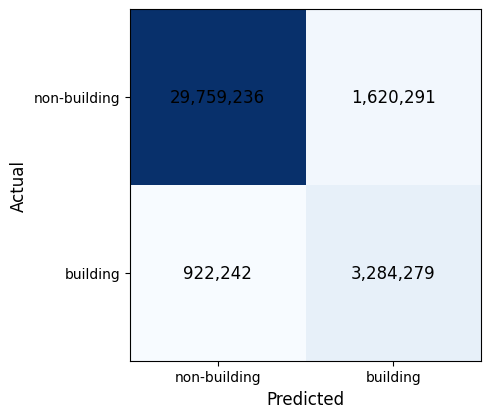

Precision: 0.6696
Recall:    0.7808


In [14]:
# Binary predictions at threshold 0.5
Yh_test = (P_test > 0.5).long().flatten()
Y_flat  = Y_test.long().flatten()

# Confusion matrix
conf_matrix = classification.BinaryConfusionMatrix()
cm = conf_matrix(Yh_test, Y_flat)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1], labels=['non-building', 'building'])
ax.set_yticks([0, 1], labels=['non-building', 'building'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j].item():,}', ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

# Precision and recall
precision = classification.BinaryPrecision()(Yh_test, Y_flat)
recall    = classification.BinaryRecall()(Yh_test, Y_flat)
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')

The log1p weighting cuts false positives from 4.2M to 1.6M, a 62% reduction which explains the large precision gain from 0.48 to 0.67. The recall drop (0.78 vs. the raw-ratio baseline) is the direct trade-off: the model is less aggressive, so it misses slightly more building pixels in exchange for far fewer spurious detections. For building footprint extraction, this is the right direction because false alarms inflate area estimates and corrupt downstream use, while modest under-detection is easier to handle.

The confusion matrix reveals two things beyond the headline metrics. First, the 29M true negatives against 3M true positives confirm how extreme the class imbalance is. Background pixels dominate so heavily that even a naive model would score well on accuracy, making precision and recall the only meaningful gauges. Second, the 922K false negatives and 1.6M false positives together suggest the remaining errors cluster at building boundaries and small structures rather than being spread uniformly, consistent with the boundary over-prediction visible in the prediction maps.

9. Implement a function to visualise true positives, true negatives, false positives, and false negatives as overlays on the input image.

We implement a function that overlays colour-coded predictions on the input aerial image. True positives are shown in green (correctly detected buildings), false positives in red (non-buildings predicted as buildings), false negatives in blue (missed buildings), and true negatives are left transparent as they represent the correctly identified background.

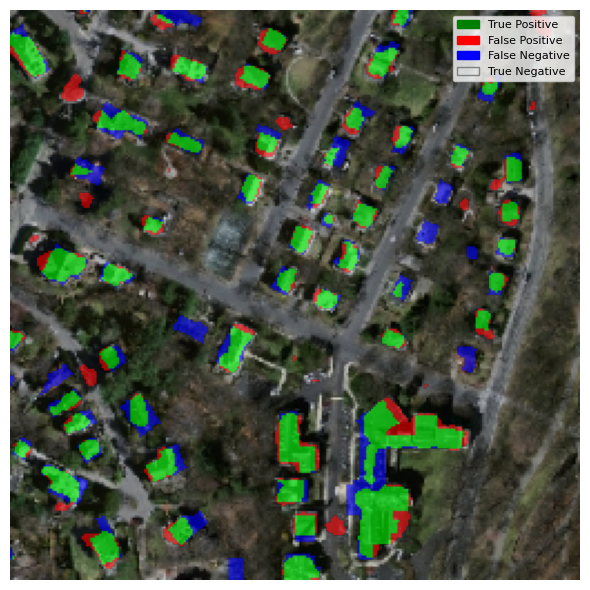

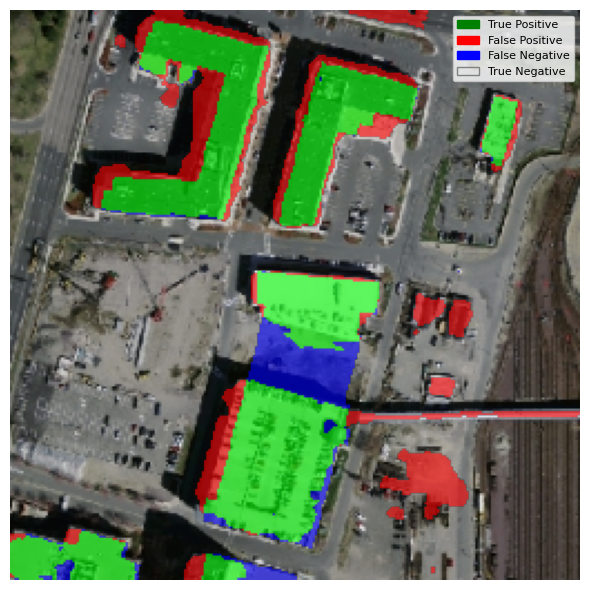

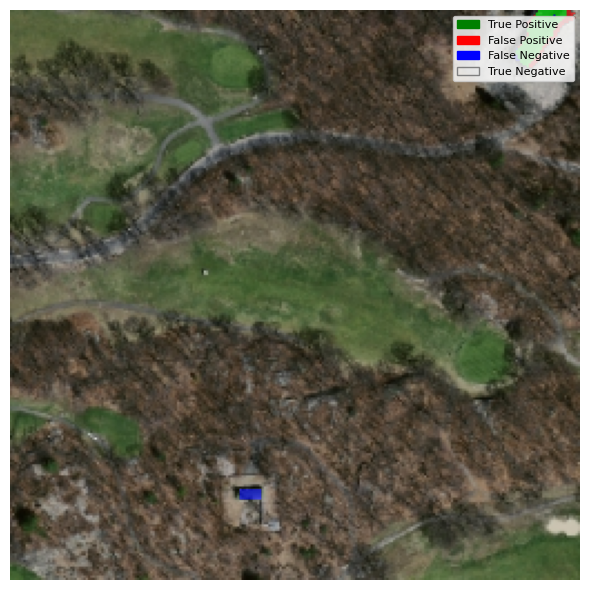

In [15]:
from matplotlib.patches import Patch

def display_predictions(image:torch.Tensor, y_true:torch.Tensor, y_pred:torch.Tensor, figsize=(6,6)) -> None:
    y_true = y_true.squeeze().bool()
    y_pred = y_pred.squeeze().bool()

    # Compute masks
    tp = y_true & y_pred
    fp = ~y_true & y_pred
    fn = y_true & ~y_pred

    # Build RGBA overlay
    overlay = torch.zeros(*y_true.shape, 4)
    overlay[tp] = torch.tensor([0.0, 1.0, 0.0, 0.6])  # green
    overlay[fp] = torch.tensor([1.0, 0.0, 0.0, 0.6])  # red
    overlay[fn] = torch.tensor([0.0, 0.0, 1.0, 0.6])  # blue

    # Display
    image = torch.einsum('dhw -> hwd', image)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.imshow(overlay.numpy())
    ax.legend(handles=[
        Patch(color='green', label='True Positive'),
        Patch(color='red',   label='False Positive'),
        Patch(color='blue',  label='False Negative'),
        Patch(facecolor='none', edgecolor='gray', label='True Negative')

    ], loc='upper right', fontsize=8)

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    plt.close()

# Display random test predictions
for i in torch.randint(0, len(test_dataset), (3,)):
    x, y = test_dataset[i]
    yh   = (P_test[i] > 0.5)
    display_predictions(image=x, y_true=y, y_pred=yh)
del i, x, y, yh

The visualisation shows the model's predictions at the default threshold of 0.50. The model successfully detects most buildings, shown in green, but tends to over-predict around building boundaries and surrounding areas, resulting in red halos. False negatives in blue are relatively rare, consistent with the recall of 0.78 observed in Task 8. The third image shows a tile with no buildings where the model correctly makes no predictions.


10. Assuming that we give equal importance to reducing false positives and false negatives, use a decision probability threshold that strikes the best balance between these two quantities.

Best threshold: 0.59
Precision:      0.7180
Recall:         0.7180


/var/folders/x0/br9762yn2tg4nwz40pbg3tg00000gn/T/ipykernel_88849/2460423823.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/oltarecica/Desktop/DL in Image Processing /sessions/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


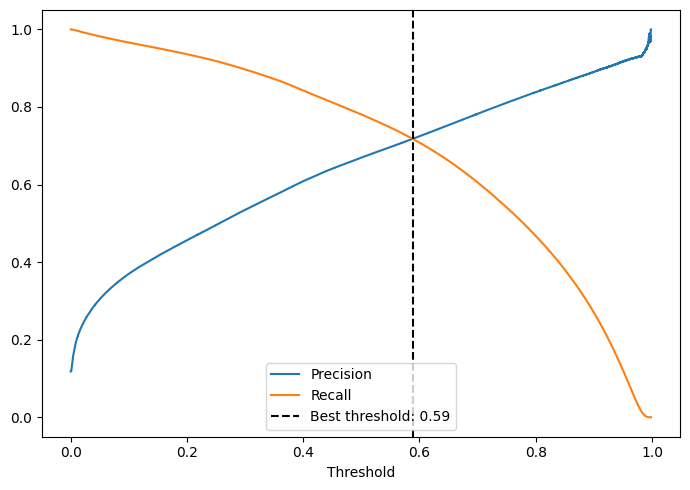

In [20]:
pr_curve     = classification.BinaryPrecisionRecallCurve()
precisions, recalls, thresholds = pr_curve(P_test.flatten(), Y_flat)

# Find threshold where |precision - recall| is minimised
best_idx       = torch.argmin(torch.abs(precisions[:-1] - recalls[:-1]))
best_threshold = thresholds[best_idx].item()
print(f'Best threshold: {best_threshold:.2f}')
print(f'Precision:      {precisions[best_idx]:.4f}')
print(f'Recall:         {recalls[best_idx]:.4f}')

# Plot
plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1],    label='Recall')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Best threshold: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.legend()
plt.tight_layout()
plt.show()

Using the precision-recall curve, we find that the optimal threshold that equally balances false positives and false negatives is 0.59, yielding a precision and recall of 0.72. This confirms that the log1p weighting produces a better calibrated model that is naturally more balanced without requiring aggressive threshold adjustment. By slightly raising the threshold from 0.50 to 0.59 we reduce false positives at a modest cost in false negatives, achieving an equal balance between the two. This is the threshold we would use in practice if we give equal importance to both types of errors. So, we apply this threshold below to re-evaluate the model and visualise the updated predictions.